## Importing dataset and visualization

In [5]:
import PRF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath('../'))
from utils import load_keel_dataset

file_path="../KEEL/keel_data/iris.dat"


X_train, X_test, y_train, y_test, label_map = load_keel_dataset(
    train_path=file_path, # Path to the WHOLE dataset (if it's not already split)
    already_split=False  # Performs the train_test split if False
) 
print("Head of training data: \n", X_train[:5])
print("Head of labels: \n", y_train[:5])

Head of training data: 
 [[5.4 3.7 1.5 0.2]
 [4.9 2.5 4.5 1.7]
 [5.5 2.4 3.8 1.1]
 [4.8 3.4 1.6 0.2]
 [5.6 2.7 4.2 1.3]]
Head of labels: 
 [1 3 2 1 2]


#### Visualization

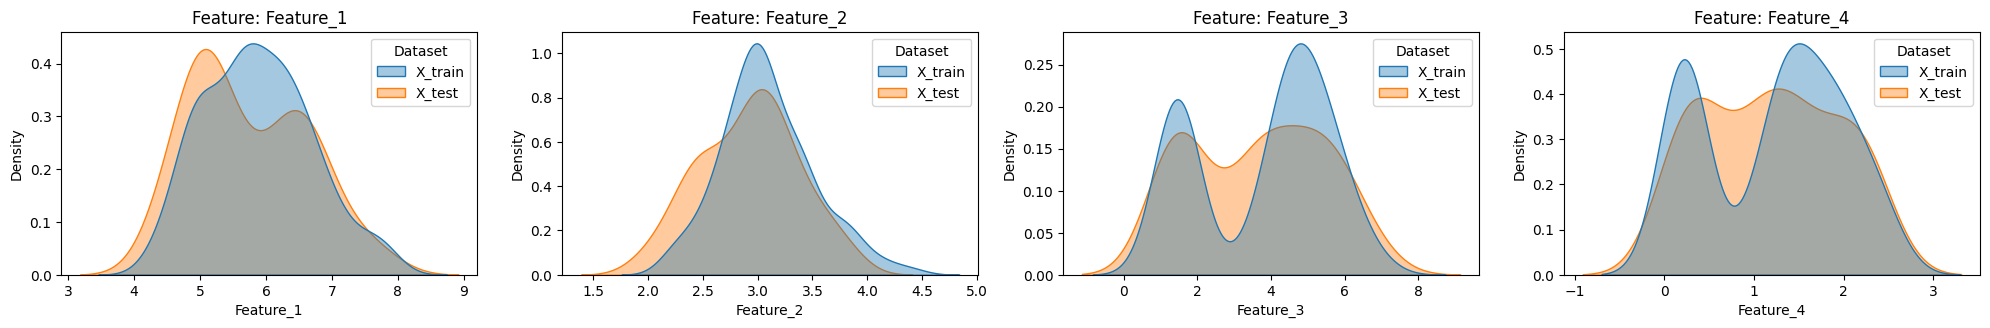

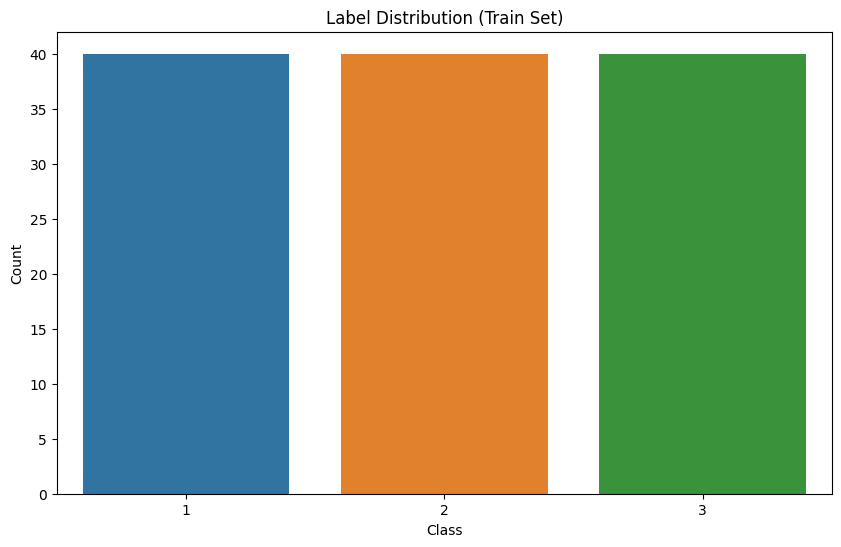

In [6]:
feature_names_train = [f'Feature_{i+1}' for i in range(X_train.shape[1])]

df1 = pd.DataFrame(X_train, columns=feature_names_train)
df1['Label'] = y_train
df1['Dataset'] = 'X_train'

feature_names_test = [f'Feature_{i+1}' for i in range(X_test.shape[1])]

df2 = pd.DataFrame(X_test, columns=feature_names_test)
df2['Label'] = y_test       # <-- Fix here: assign y_test to df2, not df1
df2['Dataset'] = 'X_test'

# Combine both train and test dataframes for plotting
df_all = pd.concat([df1, df2], ignore_index=True)

# Plot distributions of each feature side by side
plt.figure(figsize=(20, 15))
for i, feature in enumerate(feature_names_train):
    plt.subplot(5, 4, i + 1)
    sns.kdeplot(data=df_all, x=feature, hue='Dataset', common_norm=False, fill=True, alpha=0.4, bw_adjust=0.9)
    plt.title(f"Feature: {feature}")
plt.tight_layout()
plt.show()



# Plot label distribution (only for training set or combined if you want)
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df1, order=sorted(df1['Label'].unique()))
plt.title("Label Distribution (Train Set)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


#### Adding noise

In [17]:
# NOTE: THIS CODE MAKES LITTLE SENSE IF THERE ARE BOUNDS IN AN INTERVAL OF A FEATURE (LIKE IT HAS TO BE BETWEEN 0 AND 1)

from utils.noising import add_noise


X_train_noisy, _, dX, _ = add_noise(X_train, noise_type='gaussian', gaussian_scale=0.6)
# Printing noise head (dX):
print("Head of noise (dX): \n", dX[:5])



Head of noise (dX): 
 [[-0.25664806  0.9124842  -0.06737781  0.21372471]
 [ 0.12308044  1.80671407  2.73397007 -0.81428558]
 [ 2.31392386  0.58319418  0.23508132  0.69981221]
 [ 2.25198286  1.45344626  0.60231727 -0.66667946]
 [-0.88845153  0.95818776 -1.035736   -0.05995628]]


Head of noisy labels (y_train_noisy): 
 [3 2 2 1 2]


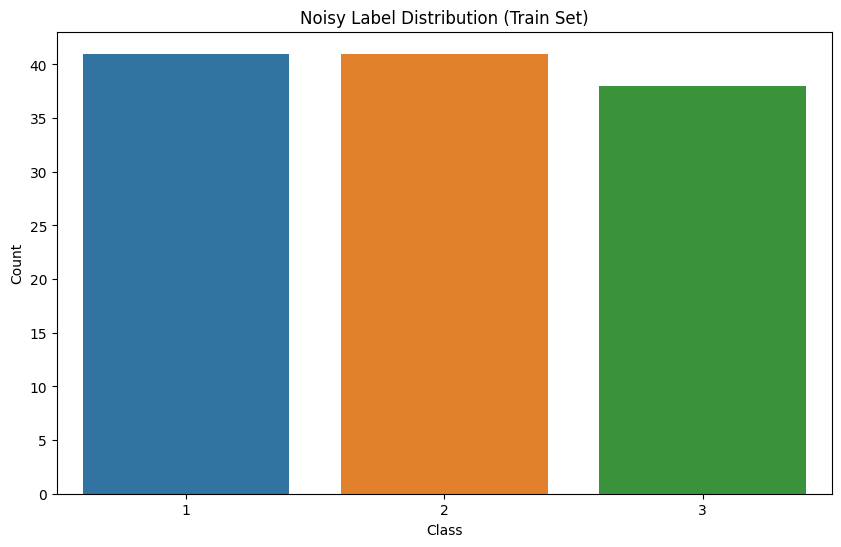

Head of label noise probabilities (pY): 
 [[0.8 0.1 0.1]
 [0.1 0.1 0.8]
 [0.  1.  0. ]
 [1.  0.  0. ]
 [0.  1.  0. ]
 [0.1 0.1 0.8]
 [0.  1.  0. ]
 [0.  0.  1. ]
 [0.1 0.1 0.8]
 [0.  0.  1. ]]


In [24]:
# TODO: Noise for labels (?), other types of noise

# Adding noise to labels

from utils.noising import add_label_noise 

y_train_noisy, _, pY, _ = add_label_noise(y_train, mode="random_prob", noise_level=0.2, random_seed=30)

# Printing noisy labels

print("Head of noisy labels (y_train_noisy): \n", y_train_noisy[:5])

# Plotting noisy labels distribution

plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=pd.DataFrame({'Label': y_train_noisy}), order=sorted(pd.Series(y_train_noisy).unique()))
plt.title("Noisy Label Distribution (Train Set)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#printing pY:
print("Head of label noise probabilities (pY): \n", pY[:10])

#### Visualizing noise

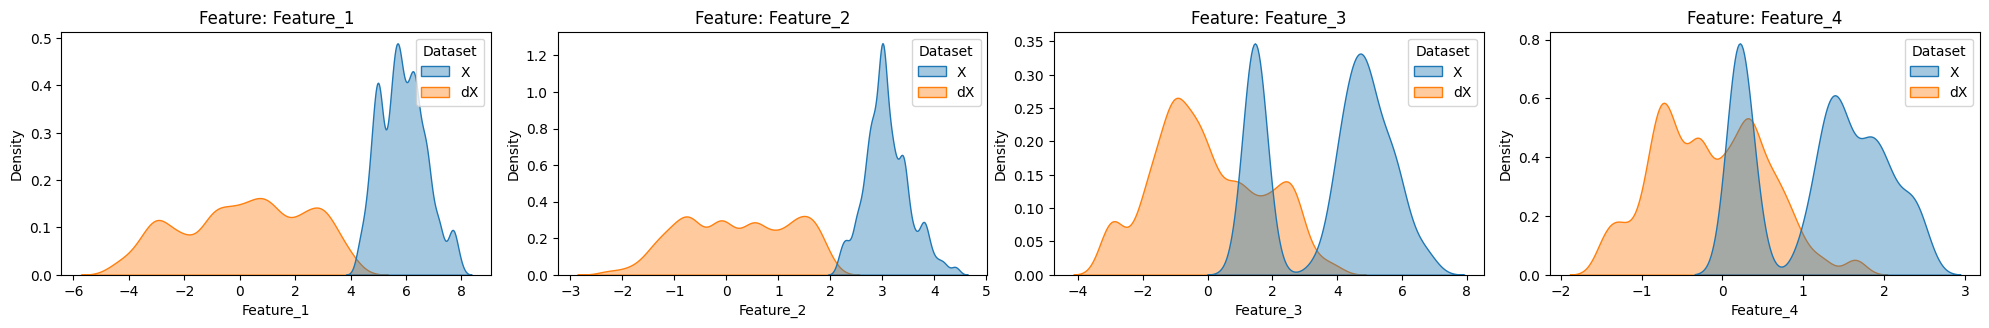

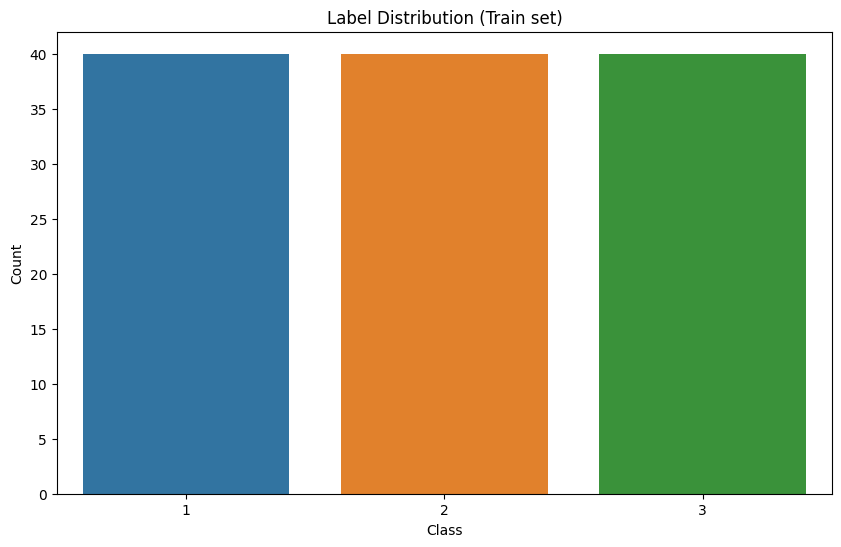

In [39]:
feature_names = [f'Feature_{i+1}' for i in range(X_train.shape[1])]

df1 = pd.DataFrame(X_train, columns=feature_names)
df1['Label'] = y_train
df1['Dataset'] = 'X'

df2 = pd.DataFrame(dX, columns=feature_names)
df2['Dataset'] = 'dX'

# Combine both for easier plotting
df_all = pd.concat([df1, df2], ignore_index=True)

# Plot distributions of each feature side by side
plt.figure(figsize=(20, 15))
for i, feature in enumerate(feature_names):
    plt.subplot(5, 4, i + 1)
    sns.kdeplot(data=df_all, x=feature, hue='Dataset', common_norm=False, fill=True, alpha=0.4, bw_adjust=0.5)
    plt.title(f"Feature: {feature}")
plt.tight_layout()
plt.show()

# Plot label distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df1, order=sorted(df1['Label'].unique()))
plt.title("Label Distribution (Train set)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## SETTING SEEDS

In [40]:
import numpy as np
import random
import tensorflow as tf
import os

def set_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

SEEDS = [27, 272, 2727, 1, 30]


## PDRF

In [41]:
from deepforest import CascadeForestClassifier
import PRF4DF

n_cascade_estimators = 1
n_classes = len(label_map)
n_features = X_train.shape[1]

accuracies_PDRF = []

for seed in SEEDS:
    set_all_seeds(seed)

    model = CascadeForestClassifier(
        n_bins=n_classes,
        random_state=seed,
    )

    prf_estimators = []
    for i in range(n_cascade_estimators):
        estimator = PRF4DF.SklearnCompatiblePRF(
            n_classes_=n_classes,
            n_features_=n_features,
            use_probabilistic_labels=False,
            use_feature_uncertainties=True,
            n_estimators=1,
            max_depth=3,
            random_state=i,
            n_jobs=1
        )
        prf_estimators.append(estimator)

    model.set_estimator(prf_estimators)

    X_train_combined = np.hstack((X_train_noisy, dX))
    model.fit(X=X_train_combined, y=y_train)

    X_test_combined = np.hstack((X_test, np.zeros_like(X_test)))
    acc = model.score(X_test_combined, y_test)
    accuracies_PDRF.append(acc)

mean_acc = np.mean(accuracies_PDRF)
std_acc = np.std(accuracies_PDRF)
print(f"PDRF Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")


[2025-06-07 12:51:57.535] Start to fit the model:
[2025-06-07 12:51:57.535] Fitting cascade layer = 0 
[2025-06-07 12:51:57.549] layer = 0  | Val Acc = 53.333 % | Elapsed = 0.014 s
[2025-06-07 12:51:57.550] Fitting cascade layer = 1 
[2025-06-07 12:51:57.562] layer = 1  | Val Acc = 48.333 % | Elapsed = 0.012 s
[2025-06-07 12:51:57.562] Early stopping counter: 1 out of 2
[2025-06-07 12:51:57.563] Fitting cascade layer = 2 
[2025-06-07 12:51:57.573] layer = 2  | Val Acc = 49.167 % | Elapsed = 0.010 s
[2025-06-07 12:51:57.573] Early stopping counter: 2 out of 2
[2025-06-07 12:51:57.573] Handling early stopping
[2025-06-07 12:51:57.574] The optimal number of layers: 1
[2025-06-07 12:51:57.574] Start to evalute the model:
[2025-06-07 12:51:57.574] Evaluating cascade layer = 0 
[2025-06-07 12:51:57.576] Start to fit the model:
[2025-06-07 12:51:57.576] Fitting cascade layer = 0 
[2025-06-07 12:51:57.585] layer = 0  | Val Acc = 62.500 % | Elapsed = 0.009 s
[2025-06-07 12:51:57.586] Fitting ca

## Other methods for classification

#### Probabilistic Random Forest

In [42]:
import PRF

accuracies_PRF = []

for seed in SEEDS:
    set_all_seeds(seed)
    prf_cls = PRF.prf(n_estimators=10, bootstrap=True)
    prf_cls.fit(X=X_train_noisy, y=y_train, dX=dX)
    score = prf_cls.score(X_test, y=y_test)
    accuracies_PRF.append(score)

mean_acc = np.mean(accuracies_PRF)
std_acc = np.std(accuracies_PRF)
print(f"PRF Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")


PRF Accuracy: 0.9000 ± 0.0211


#### Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

accuracies_RF = []

for seed in SEEDS:
    set_all_seeds(seed)
    rf = RandomForestClassifier(n_estimators=50, random_state=seed)
    rf.fit(X_train_noisy, y_train)
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_RF.append(acc)

mean_acc = np.mean(accuracies_RF)
std_acc = np.std(accuracies_RF)
print(f"Random Forest Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")


Random Forest Accuracy: 0.7400 ± 0.0904


#### Deep Forest

In [44]:
from deepforest import CascadeForestClassifier
from sklearn.metrics import accuracy_score

accuracies_DF = []

for seed in SEEDS:
    set_all_seeds(seed)
    clf = CascadeForestClassifier(n_estimators=2, random_state=seed)
    clf.fit(X_train_noisy, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies_DF.append(acc)

mean_acc = np.mean(accuracies_DF)
std_acc = np.std(accuracies_DF)
print(f"Deep Forest Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")


[2025-06-07 12:51:58.204] Start to fit the model:
[2025-06-07 12:51:58.205] Fitting cascade layer = 0 
[2025-06-07 12:51:58.521] layer = 0  | Val Acc = 64.167 % | Elapsed = 0.316 s
[2025-06-07 12:51:58.522] Fitting cascade layer = 1 
[2025-06-07 12:51:58.762] layer = 1  | Val Acc = 65.833 % | Elapsed = 0.239 s
[2025-06-07 12:51:58.763] Fitting cascade layer = 2 
[2025-06-07 12:51:58.975] layer = 2  | Val Acc = 58.333 % | Elapsed = 0.212 s
[2025-06-07 12:51:58.976] Early stopping counter: 1 out of 2
[2025-06-07 12:51:58.977] Fitting cascade layer = 3 
[2025-06-07 12:51:59.200] layer = 3  | Val Acc = 63.333 % | Elapsed = 0.224 s
[2025-06-07 12:51:59.200] Early stopping counter: 2 out of 2
[2025-06-07 12:51:59.200] Handling early stopping
[2025-06-07 12:51:59.201] The optimal number of layers: 2
[2025-06-07 12:51:59.202] Start to evalute the model:
[2025-06-07 12:51:59.202] Evaluating cascade layer = 0 
[2025-06-07 12:51:59.207] Evaluating cascade layer = 1 
[2025-06-07 12:51:59.213] Star

#### Neural Network

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from scikeras.wrappers import KerasClassifier

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # CPU only

accuracies_NN = []

unique_classes = np.unique(y_train)
num_classes = len(unique_classes)
is_binary = num_classes == 2

if not is_binary:
    y_train_cat = to_categorical(np.searchsorted(unique_classes, y_train))
    y_test_cat = to_categorical(np.searchsorted(unique_classes, y_test))
else:
    y_train_cat = y_train
    y_test_cat = y_test

def create_model(hidden_units=64, dropout_rate=0.5, optimizer='adam'):
    model = Sequential()
    model.add(Dense(hidden_units, input_shape=(X_train.shape[1],), activation='relu'))
    model.add(Dropout(dropout_rate))
    if is_binary:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    else:
        model.add(Dense(num_classes, activation='softmax'))
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

for seed in SEEDS:
    set_all_seeds(seed)
    
    model = KerasClassifier(model=create_model, hidden_units=64, dropout_rate=0.5,
                            optimizer='adam', epochs=20, batch_size=16, verbose=0)
    
    model.fit(X_train_noisy, y_train_cat)

    if is_binary:
        y_pred = model.predict(X_test)
        y_true = y_test
    else:
        y_pred = np.argmax(model.predict_proba(X_test), axis=1)
        y_true = np.searchsorted(unique_classes, y_test)

    acc = accuracy_score(y_true, y_pred)
    accuracies_NN.append(acc)

mean_acc = np.mean(accuracies_NN)
std_acc = np.std(accuracies_NN)
print(f"Neural Network Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")


Neural Network Accuracy: 0.7933 ± 0.1555


#### Bayesian Logistic Regression (??)

#### Kernel SVM

In [46]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

accuracies_KSVM = []

# Use first seed for reproducibility
set_all_seeds(SEEDS[0])

# Define model and parameter grid
model = SVC()
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# Perform GridSearchCV once
grid = GridSearchCV(model, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train_noisy, y_train)

# Get best model
best_svm = grid.best_estimator_

# Predict and evaluate
y_pred = best_svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# Repeat accuracy 5 times to match output shape of other models
accuracies_KSVM = [acc] * len(SEEDS)

# Print mean ± std
mean_acc = np.mean(accuracies_KSVM)
std_acc = np.std(accuracies_KSVM)
print(f"Kernel SVM Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")


Kernel SVM Accuracy: 0.8333 ± 0.0000


## Results Comparison

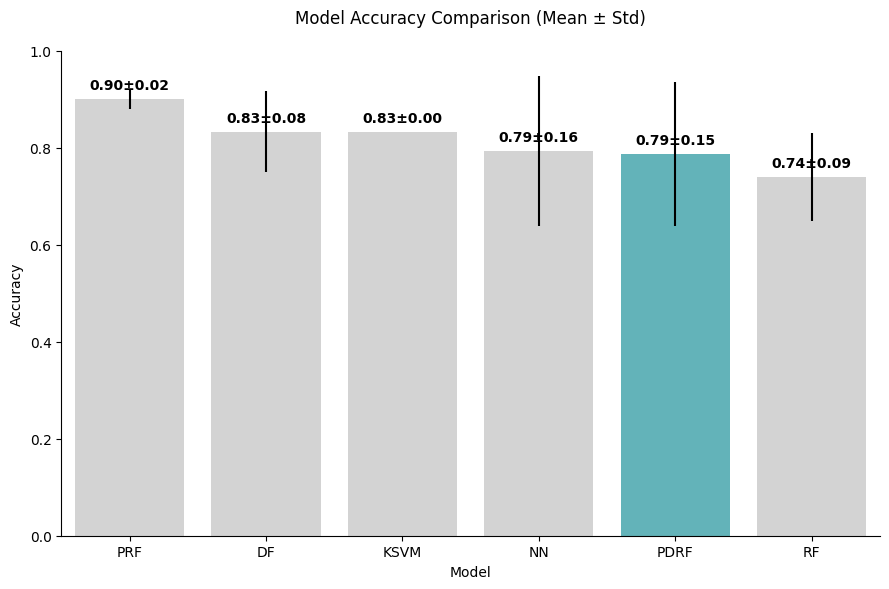

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Build comparison DataFrame
comparison_df = pd.DataFrame({
    "Model": ["PDRF", "PRF", "DF", "RF", "NN", "KSVM"],
    "Mean Accuracy": [
        np.mean(accuracies_PDRF),
        np.mean(accuracies_PRF),
        np.mean(accuracies_DF),
        np.mean(accuracies_RF),
        np.mean(accuracies_NN),
        np.mean(accuracies_KSVM),
    ],
    "Std": [
        np.std(accuracies_PDRF),
        np.std(accuracies_PRF),
        np.std(accuracies_DF),
        np.std(accuracies_RF),
        np.std(accuracies_NN),
        np.std(accuracies_KSVM),
    ]
})

# Sort for display
comparison_df = comparison_df.sort_values("Mean Accuracy", ascending=False)

# Custom colors
def get_color(model):
    return "#55bfc7" if model == "PDRF" else "lightgray"

colors = comparison_df["Model"].apply(get_color)

# Plot
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=comparison_df, 
    x="Model", 
    y="Mean Accuracy", 
    palette=colors, 
    yerr=comparison_df["Std"]
)

sns.despine()
plt.title("Model Accuracy Comparison (Mean ± Std)", pad=20)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)

# Annotate values
for p, std in zip(ax.patches, comparison_df["Std"]):
    height = p.get_height()
    ax.annotate(f'{height:.2f}±{std:.2f}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


#### Saving results

In [48]:
results_df = pd.DataFrame({
    "Model": ["PDRF", "PRF", "DF", "RF", "NN", "KSVM"],
    "Mean Accuracy": [
        np.mean(accuracies_PDRF),
        np.mean(accuracies_PRF),
        np.mean(accuracies_DF),
        np.mean(accuracies_RF),
        np.mean(accuracies_NN),
        np.mean(accuracies_KSVM),
    ],
    "Std": [
        np.std(accuracies_PDRF),
        np.std(accuracies_PRF),
        np.std(accuracies_DF),
        np.std(accuracies_RF),
        np.std(accuracies_NN),
        np.std(accuracies_KSVM),
    ],
    "Seeds": [SEEDS] * 6
})

results_df.to_csv("model_accuracy_summary.csv", index=False)
print("Saved to model_accuracy_summary.csv")


Saved to model_accuracy_summary.csv
